# Meep FDTD

[Meep](https://meep.readthedocs.io/en/latest/) is a free and open source finite-difference time-domain (FDTD) software package for electromagnetic simulations spanning a broad range of applications.

You can install Meep, NLOPT and the mode solver MPB (which Meep uses to compute S-parameters and launch mode sources) using  Conda

Make sure you install python 3.11 or later

for example


```
conda create -n mp python=3.11
conda activate mp
conda install -c conda-forge pymeep pymeep-extras
```

If you are on MacOs with apple silicon (M1, M2, M3, M4)


```
CONDA_SUBDIR=osx-arm64 conda create -n mp -c conda-forge pymeep pymeep-extras python=3.11

```

The Conda packages are available for Linux, macOS, or Windows [WSL](https://docs.microsoft.com/en-us/windows/wsl/). For more details on installing Meep, see the [user manual](https://meep.readthedocs.io/en/latest/Installation/#conda-packages).


The gdsfactory `gmeep` plugin computes the transmission spectrum for planar photonic components.

One advantage of using the `gmeep` plugin is that you only need to define your component geometry once using gdsfactory. The geometry is automatically imported into Meep, so there is no need to define the geometry separately for Meep.

For extracting S-parameters, `gmeep` automatically swaps the source between ports to compute the full S-matrix. This process involves:

- adding monitors to each port of the device
- extending the ports into the PML absorbing boundary layers
- running the simulation and computing elements of the S-matrix in post-processing using the correct ratio of S-parameters. The port monitors are used to compute the discrete-time Fourier-transformed (DTFT) fields which are then decomposed into complex mode coefficients known as S-parameters. The S-parameters can be computed over a range of frequencies.

The resolution is in units of pixels/μm. As a general rule, you should run with at least `resolution=30` for 1/30 μm/pixel (33 nm/pixel)

Note that most of the examples use `resolution=20` in order to run fast.

Here are some examples of how to extract S-parameters in Meep in planar devices.

For Sparameters we follow the syntax `o1@0,o2@0` where `o1` is the input port `@0` mode 0 (usually fundamental TE mode) and `o2@0` refers to output port `o2` mode 0.

To speed up the simulations below we define the file to save `filepath` and automatically loads the simulation results when the file already exists.


```bash

         top view
              ________________________________
             |                               |
             | xmargin_left                  | port_extension
             |<--------->       port_margin ||<-->
          o2_|___________          _________||_o3
             |           \        /          |
             |            \      /           |
             |             ======            |
             |            /      \           |
          o1_|___________/        \__________|_o4
             |   |                 <-------->|
             |   |ymargin_bot   xmargin_right|
             |   |                           |
             |___|___________________________|

        side view
              ________________________________
             |                     |         |
             |                     |         |
             |                   zmargin_top |
             |xmargin_left         |         |
             |<---> _____         _|___      |
             |     |     |       |     |     |
             |     |     |       |     |     |
             |     |_____|       |_____|     |
             |       |                       |
             |       |                       |
             |       |zmargin_bot            |
             |       |                       |
             |_______|_______________________|



```

## Serial Simulation (single core)

Running Meep using a single CPU core can be slow as the single core needs to update all the simulation grid points sequentially at each time step.

In [1]:
import gdsfactory as gf
import matplotlib.pyplot as plt
import meep as mp
import numpy as np
import os
from meep import MaterialGrid, Medium, Vector3, Volume
from meep.adjoint import (
    DesignRegion,
    get_conic_radius_from_eta_e,
)

import gplugins
import gplugins.gmeep as gm
from gplugins.gmeep.get_simulation import get_simulation

gf.config.rich_output()
gf.gpdk.PDK.activate() # This ensures the generic PDK is globally registered
gf.get_active_pdk() # Check if one is active

Using MPI version 4.1, 1 processes
2026-01-21 19:23:00.999 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep']



Pdk(
    name='generic',
    version='9.29.1',
    cross_sections={
        'strip': <function strip at 0x79e771ae0cc0>,
        'strip_no_ports': <function strip_no_ports at 0x79e771ae0e00>,
        'rib': <function rib at 0x79e771ae0f40>,
        'rib_bbox': <function rib_bbox at 0x79e771ae1080>,
        'rib2': <function rib2 at 0x79e771ae11c0>,
        'nitride': <function nitride at 0x79e771ae1300>,
        'strip_rib_tip': <function strip_rib_tip at 0x79e771ae1440>,
        'strip_nitride_tip': <function strip_nitride_tip at 0x79e771ae1580>,
        'slot': <function slot at 0x79e771ae16c0>,
        'rib_with_trenches': <function rib_with_trenches at 0x79e771ae1800>,
        'l_with_trenches': <function l_with_trenches at 0x79e771ae1940>,
        'metal1': <function metal1 at 0x79e771ae1a80>,
        'metal2': <function metal2 at 0x79e771ae1bc0>,
        'metal3': <function metal3 at 0x79e771ae1d00>,
        'gs': <function gs at 0x79e771ae1e40>,
        'gsg': <function gsg at 

In [2]:
# Create the data directory if it doesn't exist
if not os.path.exists("data"):
    os.makedirs("data")

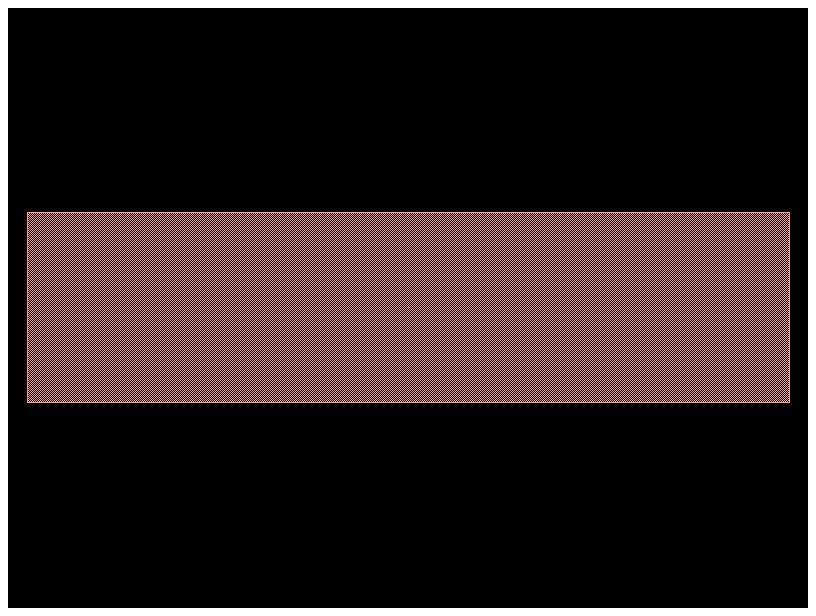

In [3]:
c = gf.components.straight(length=2)
c.plot()

`run=False` only plots the simulations for you to review that is set up **correctly**

/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/visualization.py:966: UserWarning: plot_eps_flag is deprecated. Use show_epsilon instead.
  warnings.warn("plot_eps_flag is deprecated. Use show_epsilon instead.")
/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/__init__.py:4446: ComplexWarning: Casting complex values to real discards the imaginary part
  return _meep._get_epsilon_grid(gobj_list, mlist, _default_material, _ensure_periodicity, gv, cell_size, cell_center, nx, xtics, ny, ytics, nz, ztics, grid_vals, frequency)


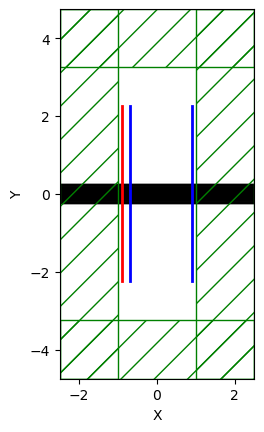

In [4]:
sp = gm.write_sparameters_meep(c, run=False, ymargin_top=3, ymargin_bot=3, is_3d=False)

In [5]:
help(gm.write_sparameters_meep)

Help on function write_sparameters_meep in module gplugins.gmeep.write_sparameters_meep:

write_sparameters_meep(component: 'ComponentSpec', port_source_names: 'list[str] | None' = None, port_source_modes: 'dict[str, list] | None' = None, port_modes: 'list[int] | None' = None, port_symmetries: 'PortSymmetries | None' = None, resolution: 'int' = 30, wavelength_start: 'float' = 1.5, wavelength_stop: 'float' = 1.6, wavelength_points: 'int' = 50, dirpath: 'PathType | None' = None, layer_stack: 'LayerStack | None' = None, port_margin: 'float' = 2, port_monitor_offset: 'float' = -0.1, port_source_offset: 'float' = -0.1, filepath: 'Path | None' = None, overwrite: 'bool' = False, animate: 'bool' = False, animate_center: 'tuple[float, float, float] | None' = None, animate_size: 'tuple[float, float, float] | None' = None, lazy_parallelism: 'bool' = False, run: 'bool' = True, dispersive: 'bool' = False, xmargin: 'float' = 0, ymargin: 'float' = 0, zmargin: 'float' = 0, xmargin_left: 'float' = 0, x

As you've noticed we added `ymargin_top` and `ymargin_bot` to ensure we have enough distance to the PML

You can also do this directly with another version of the function that adds `ymargin_top` and `ymargin_bot`

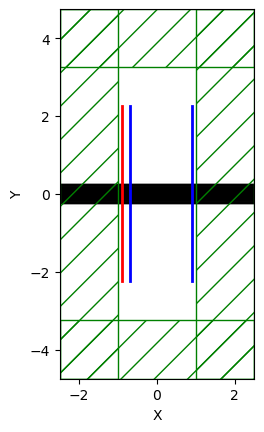

In [6]:
c = gf.components.straight(length=2)
sp = gm.write_sparameters_meep(c, run=False, is_3d=False, ymargin_top=3, ymargin_bot=3)

Because components with `left-right` ports are very common `write_sparameters_meep` `y_margin = 3um `

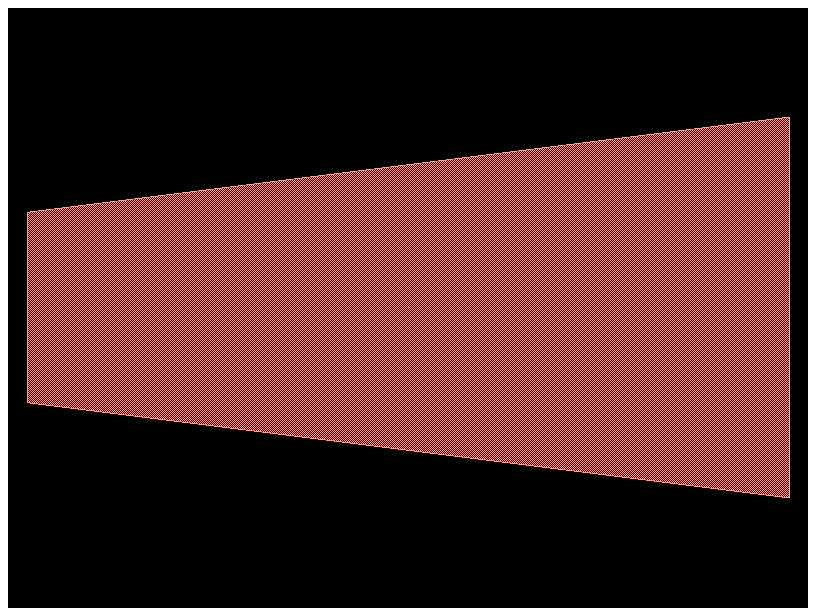

In [7]:
c = gf.components.taper(length=2.0, width1=0.5, width2=1)
c.plot()

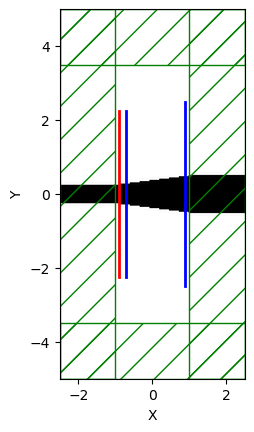

In [8]:
sp = gm.write_sparameters_meep(c, run=False, ymargin_top=3, ymargin_bot=3)

## 2.5D Simulation

For faster simulations you can do an effective mode approximation, to compute the mode of the slab and run a 2D simulation to speed your [simulations](https://www.lumerical.com/learn/whitepapers/lumericals-2-5d-fdtd-propagation-method/)

In [9]:
core_material = gplugins.get_effective_indices(
    core_material=3.4777,
    clad_materialding=1.444,
    nsubstrate=1.444,
    thickness=0.22,
    wavelength=1.55,
    polarization="te",
)[0]

core_material

2.8494636999424405

In [10]:
sp = gm.write_sparameters_meep(
    c,
    ymargin_top=3,
    ymargin_bot=3,
    resolution=20,
    is_3d=False,
    material_name_to_meep=dict(si=core_material),
    filepath="data/taper.npz",
)

2026-01-21 19:23:02.796 | INFO     | gplugins.gmeep.write_sparameters_meep:write_sparameters_meep:397 - Simulation loaded from PosixPath('data/taper.npz')


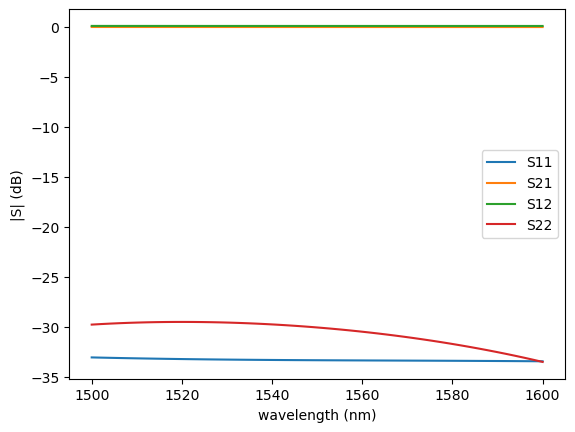

In [11]:
gplugins.plot.plot_sparameters(sp)

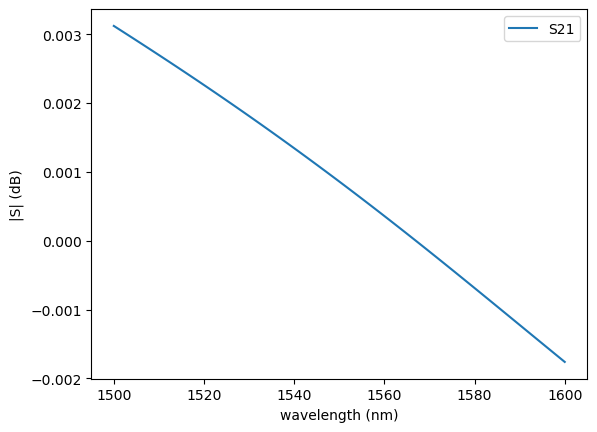

In [12]:
gplugins.plot.plot_sparameters(sp, keys=("o2@0,o1@0",))

For a small taper length, the matrix element S$_{21}$ (transmission in Port 2 given a source in Port 1) is around 0 dB which is equivalent to ~100% transmission.

## Port Symmetries

You can skip redundant simulations in reciprocal devices.
If the device looks the same going from in -> out as out -> in, we just need to run one simulation.

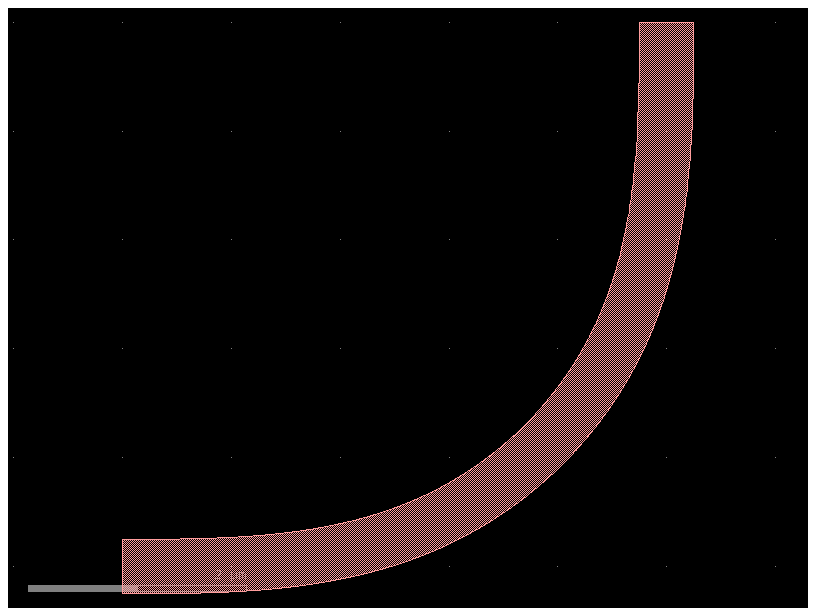

In [13]:
c = gf.components.bend_euler(radius=5)
c.plot()

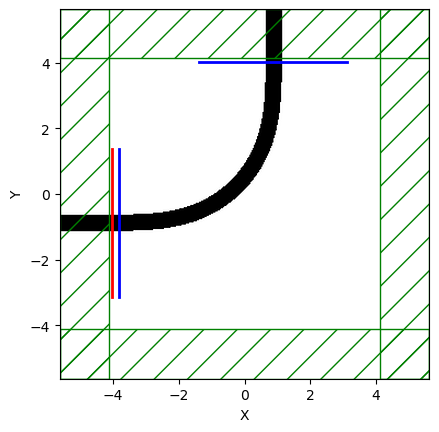

In [14]:
sp = gm.write_sparameters_meep_1x1_bend90(c, run=False)

In [15]:
sp = gm.write_sparameters_meep_1x1_bend90(c, run=True, filepath="data/bend90_meep.npz")

2026-01-21 19:23:03.975 | INFO     | gplugins.gmeep.write_sparameters_meep:write_sparameters_meep:397 - Simulation loaded from PosixPath('data/bend90_meep.npz')


In [16]:
list(sp.keys())

['o1@0,o1@0', 'o2@0,o1@0', 'o1@0,o2@0', 'o2@0,o2@0', 'wavelengths']

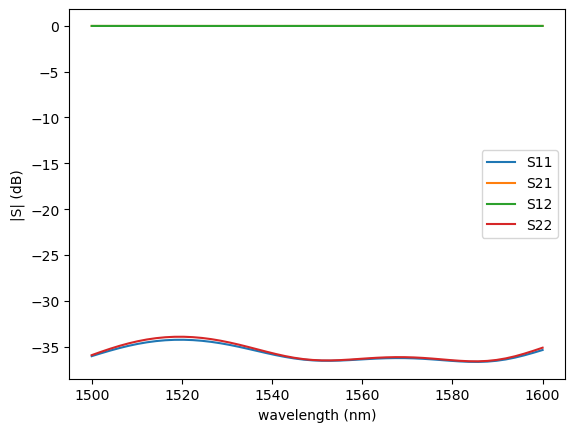

In [17]:
gplugins.plot.plot_sparameters(sp)

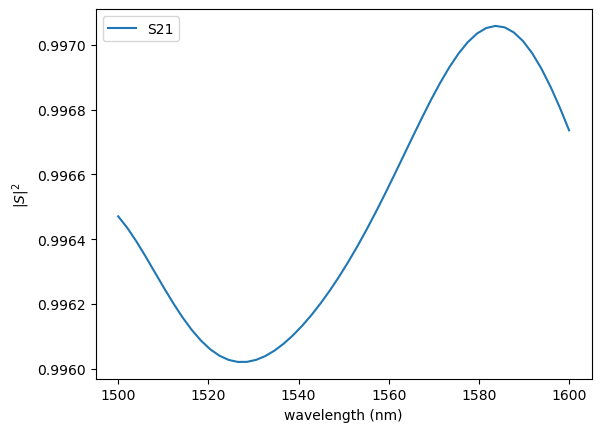

In [18]:
gplugins.plot.plot_sparameters(sp, keys=("o2@0,o1@0",), logscale=False)

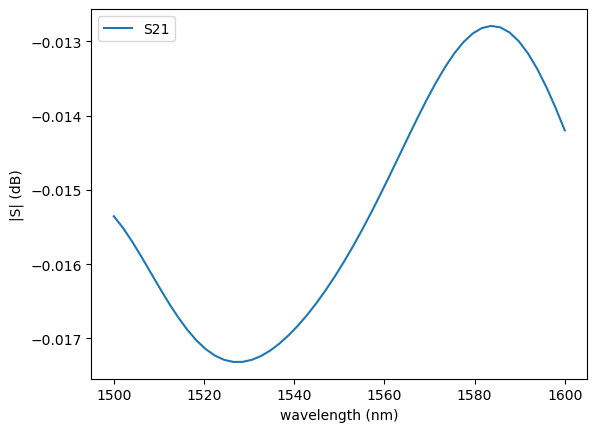

In [19]:
gplugins.plot.plot_sparameters(sp, keys=("o2@0,o1@0",))

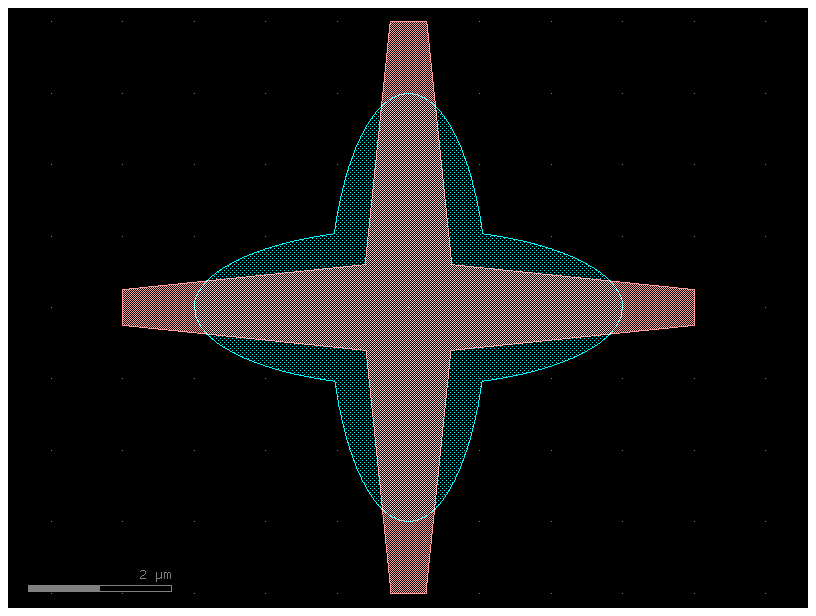

In [20]:
c = gf.components.crossing()
c.plot()

Here are the port symmetries for a crossing

```python
port_symmetries_crossing = {
    "o1": {
        "o1@0,o1@0": ["o2@0,o2@0", "o3@0,o3@0", "o4@0,o4@0"],
        "o2@0,o1@0": ["o1@0,o2@0", "o3@0,o4@0", "o4@0,o3@0"],
        "o3@0,o1@0": ["o1@0,o3@0", "o2@0,o4@0", "o4@0,o2@0"],
        "o4@0,o1@0": ["o1@0,o4@0", "o2@0,o3@0", "o3@0,o2@0"],
    }
}
```

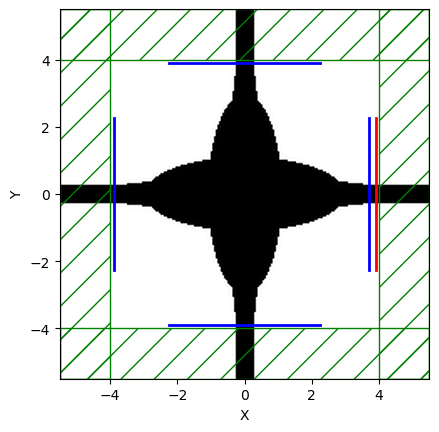

In [21]:
sp = gm.write_sparameters_meep(
    c,
    resolution=20,
    ymargin=0,
    port_symmetries=gm.port_symmetries.port_symmetries_crossing,
    run=False,
)

In [22]:
sp = gm.write_sparameters_meep(
    c,
    resolution=20,
    ymargin=0,
    port_symmetries=gm.port_symmetries.port_symmetries_crossing,
    run=True,
    filepath="data/meep_crossing.npz",
)

2026-01-21 19:23:05.323 | INFO     | gplugins.gmeep.write_sparameters_meep:write_sparameters_meep:397 - Simulation loaded from PosixPath('data/meep_crossing.npz')


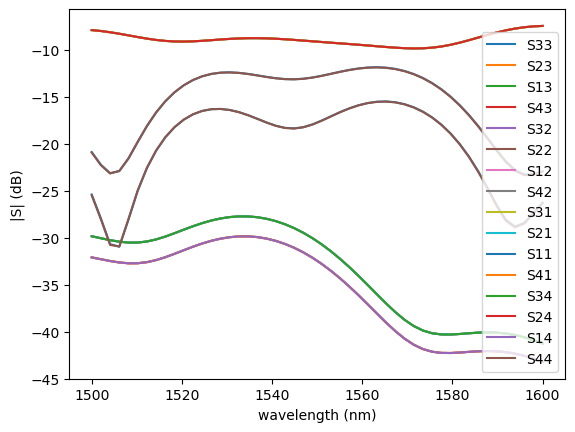

In [23]:
gm.plot.plot_sparameters(sp)

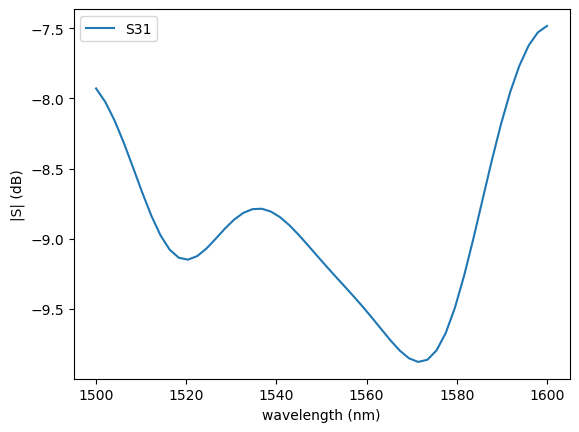

In [24]:
gm.plot.plot_sparameters(sp, keys=("o3@0,o1@0",))

As you can see this crossing looks beautiful but is quite **lossy** (9 dB @ 1550 nm)

## Multimode Simulations
You can also simulate structures that source and measure multiple modes. We define the `port_source_modes` as a dictionary with the keys as the source keys and the values as list of mode numbers to output (starting at 0 for TE00). Similarly on the output ports, `port_modes` is a list of modes to measure at every output port.

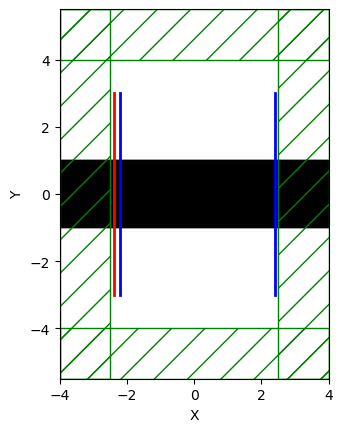

In [25]:
c = gf.components.straight(length=5, width=2)
sp = gm.write_sparameters_meep(
    c,
    run=False,
    ymargin_top=3,
    ymargin_bot=3,
    is_3d=False,
    resolution=20,
)

2026-01-21 19:23:06.001 | INFO     | gplugins.gmeep.write_sparameters_meep:write_sparameters_meep:397 - Simulation loaded from PosixPath('/tmp/gdsfactory/sparameters/straight_gdsfactorypcomponentspwaveguidespstraight_L5_N_019dcc11/straight_gdsfactorypcomponentspwaveguidespstraight_L5_N_019dcc11_fd6981b80aca6c524db28998c6c3faac.npz')


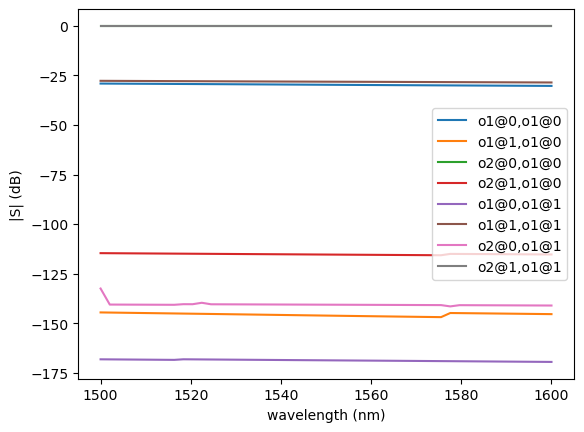

In [26]:
sp = gm.write_sparameters_meep(
    c,
    run=True,
    ymargin_top=3,
    ymargin_bot=3,
    is_3d=False,
    port_source_names=["o1"],
    port_source_modes={"o1": [0, 1]},
    port_modes=[0, 1],
    resolution=20,
    overwrite=False,
)
gm.plot.plot_sparameters(sp, with_simpler_labels=False)

## Parallel Simulation (multicore/MPI)

Meep supports [distributed-memory parallelization via MPI](https://meep.readthedocs.io/en/latest/Parallel_Meep/) which can be used to provide a significant speedup compared to serial calculations.

By default MPI just runs the same copy of the Python script everywhere, with the C++ under MEEP actually being parallelized.

`divide_parallel_processes` allows us to logically split this one calculation into (in this case "cores") subdivisions.
The only difference in the scripts is that a different integer n is returned depending on the subdivision it is running in.

So we use that n to select different sources, and each subdivision calculates its own Sparams independently.
Afterwards, we collect all the results in one of the subdivisions (if rank == 0)

As a demonstration, lets try to reproduce the results of the directional coupler results from the [Meep manual](https://meep.readthedocs.io/en/latest/Python_Tutorials/GDSII_Import/) which indicates that to obtain a 3 dB (50%/50%) splitter you need a separation distance of 130 nm over a coupler length of 8 μm.

In [27]:
help(gf.components.coupler)

Help on function coupler in module gdsfactory.components.couplers.coupler:

coupler(gap: 'float' = 0.236, length: 'float' = 20.0, dy: 'Delta' = 4.0, dx: 'Delta' = 10.0, cross_section: 'CrossSectionSpec' = 'strip', allow_min_radius_violation: 'bool' = False, bend: 'ComponentSpec' = 'bend_s') -> 'Component'
    Symmetric coupler.
    
    Args:
        gap: between straights in um.
        length: of coupling region in um.
        dy: port to port vertical spacing in um.
        dx: length of bend in x direction in um.
        cross_section: spec (CrossSection, string or dict).
        allow_min_radius_violation: if True does not check for min bend radius.
        bend: input and output sbend components.
    
    .. code::
    
               dx                                 dx
            |------|                           |------|
         o2 ________                           ______o3
                    \                         /           |
                     \        length   

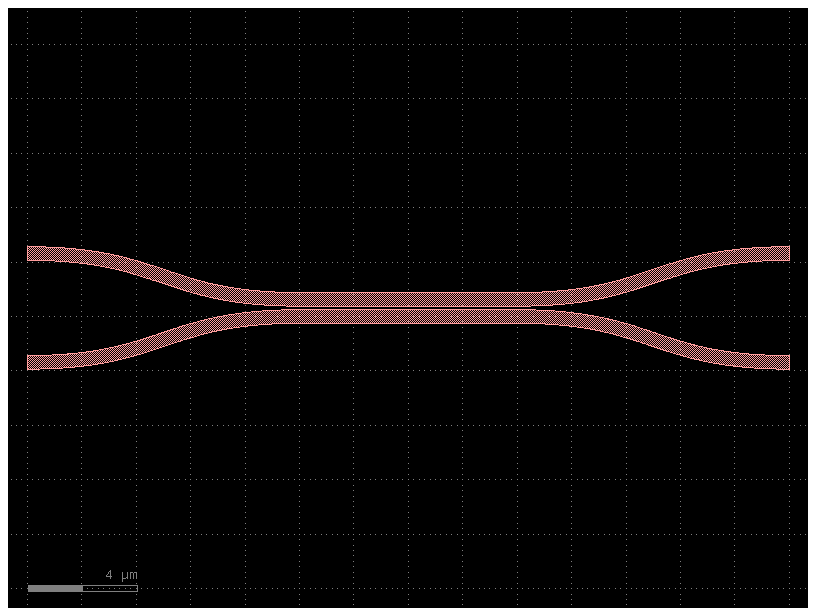

In [28]:
c = gf.components.coupler(length=8, gap=0.13)
c.plot()

In [29]:
%%writefile run_meep_mpi.py
import gdsfactory as gf
import gplugins.gmeep as gm

# ==============================================================================
# 1. CRITICAL: Activate the PDK
#    This fixes the "No active PDK" error by ensuring the new process
#    loads the generic PDK layers before Meep starts.
# ==============================================================================
gf.gpdk.PDK.activate()

# 2. Define the Component
#    (Ensure this matches the component you want to simulate)
c = gf.components.coupler(length=8, gap=0.13)

# 3. Run Simulation
#    We use the standard serial function. Meep's MPI backend handles the
#    parallelism when this script is executed via 'mpirun'.
if __name__ == "__main__":
    gm.write_sparameters_meep(
        component=c,
        run=True,
        resolution=30,
        filepath="data/meep_coupler_mpi.npz",
        
        # Explicit margins to ensure ports are inside the simulation region
        ymargin_top=3.0,
        ymargin_bot=3.0,
        xmargin_left=2.0,
        xmargin_right=2.0,
        
        is_3d=False
    )

Overwriting run_meep_mpi.py


In [30]:
# Run on 4 cores using the script we just created
!mpirun -np 8 python run_meep_mpi.py

Using MPI version 4.1, 8 processes
2026-01-21 19:23:13.434 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep']
2026-01-21 19:23:13.442 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep']
2026-01-21 19:23:13.444 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep']
2026-01-21 19:23:13.449 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep']
2026-01-21 19:23:13.456 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep']
2026-01-21 19:23:13.477 | INFO     | gplugins.gmeep:<module>:39 - Meep '1.31.0' installed at ['/home/aitor/miniconda/envs/pho

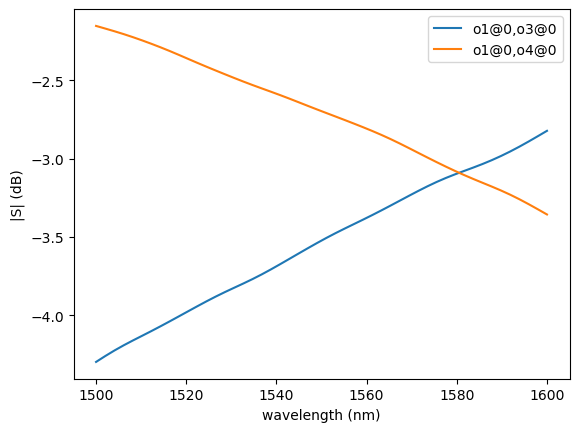

In [31]:
# Load the file generated by the MPI run
sp = np.load("data/meep_coupler_mpi.npz")

# Plot
gm.plot.plot_sparameters(sp, keys=["o1@0,o3@0", "o1@0,o4@0"], with_simpler_labels=False)

## Batch Simulations

You can also run a batch of multicore simulations.

Given a list of write_sparameters_meep keyword arguments `jobs` launches them in different cores using MPI where each simulation runs with "cores_per_run" cores.

If there are more simulations than cores each batch runs sequentially.

In [32]:
help(gm.write_sparameters_meep_batch)

Help on function write_sparameters_meep_batch in module gplugins.gmeep.write_sparameters_meep_batch:

write_sparameters_meep_batch(jobs: 'list[dict]', cores_per_run: 'int' = 2, total_cores: 'int' = 4, temp_dir: 'Path' = PosixPath('/home/aitor/.gdsfactory/sp/temp'), delete_temp_files: 'bool' = True, dirpath: 'Path | None' = None, layer_stack: 'LayerStack | None' = None, **kwargs) -> 'list[Path]'
    Write Sparameters for a batch of jobs using MPI and returns results filepaths.
    
    Given a list of write_sparameters_meep keyword arguments `jobs` launches them in
    different cores using MPI where each simulation runs with `cores_per_run` cores.
    If there are more simulations than cores each batch runs sequentially.
    
    
    Args:
        jobs: list of Dicts containing the simulation settings for each job.
            for write_sparameters_meep.
        cores_per_run: number of processors to assign to each component simulation.
        total_cores: total number of cores to us

In [33]:
c = gf.components.straight(length=3.1)

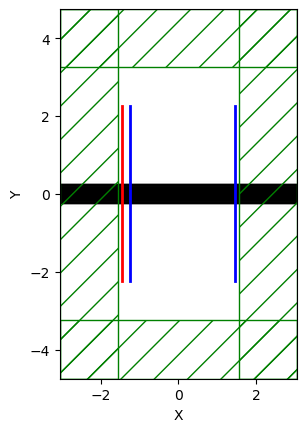

In [34]:
gm.write_sparameters_meep(c, ymargin=3, run=False)

In [35]:
c1_dict = {"component": c, "ymargin": 3}
jobs = [
    c1_dict,
]

filepaths = gm.write_sparameters_meep_batch_1x1(
    jobs=jobs,
    cores_per_run=4,
    total_cores=8,
    lazy_parallelism=True,
    is_3d=False,
    filepath='data/meep_straight3.npz'
)
sp = np.load(filepaths[0])
gplugins.plot.plot_sparameters(sp)

2026-01-21 19:23:17.200 | INFO     | gplugins.gmeep.write_sparameters_meep_batch:write_sparameters_meep_batch:137 - Simulation PosixPath('/tmp/gdsfactory/sparameters/straight_gdsfactorypcomponentspwaveguidespstraight_L3p1_2353d26b/straight_gdsfactorypcomponentspwaveguidespstraight_L3p1_2353d26b_19d12956aa70237209bea319e70b2761.npz') not found. Adding it to the queue
2026-01-21 19:23:17.203 | INFO     | gplugins.gmeep.write_sparameters_meep_batch:write_sparameters_meep_batch:145 - Running 1 simulations
2026-01-21 19:23:17.206 | INFO     | gplugins.gmeep.write_sparameters_meep_batch:write_sparameters_meep_batch:146 - total_cores = 8 with cores_per_run = 4
2026-01-21 19:23:17.210 | INFO     | gplugins.gmeep.write_sparameters_meep_batch:write_sparameters_meep_batch:147 - Running 1 batches with up to 2 jobs each.


  0%|          | 0/1 [00:00<?, ?it/s]

{2026-01-21 19:23:17.223 | INFO     | gplugins.gmeep.write_sparameters_meep_batch:write_sparameters_meep_batch:158 - Task 0 of batch 0 is job 0
'component': Component(name=straight_gdsfactorypcomponentspwaveguidespstraight_L3p1_2353d26b, ports=['o1', 'o2'], pins=[], instances=[], locked=True, kcl=DEFAULT),
 'ymargin': 3}
2026-01-21 19:23:17.231 | INFO     | gplugins.gmeep.write_sparameters_meep_mpi:write_sparameters_meep_mpi:159 - Write PosixPath('/home/aitor/.gdsfactory/sp/temp/write_sparameters_meep_mpi_0.json')
2026-01-21 19:23:17.238 | INFO     | gplugins.gmeep.write_sparameters_meep_mpi:write_sparameters_meep_mpi:195 - mpirun -np 4 /home/aitor/miniconda/envs/photonics/bin/python /home/aitor/.gdsfactory/sp/temp/write_sparameters_meep_mpi_0.py
2026-01-21 19:23:17.239 | INFO     | gplugins.gmeep.write_sparameters_meep_mpi:write_sparameters_meep_mpi:196 - /tmp/gdsfactory/sparameters/straight_gdsfactorypcomponentspwaveguidespstraight_L3p1_2353d26b/straight_gdsfactorypcomponentspwavegui

KeyboardInterrupt: 

## Adjoint Optimization

gdsfactory extends Meep's Adjoint Optimization features to optimize and generate primitive photonic components.

This example is based on this [Meep Adjoint Optimization tutorial](https://nbviewer.org/github/NanoComp/meep/blob/master/python/examples/adjoint_optimization/04-Splitter.ipynb)

We define some useful variables that we will need later. We can leave out many of the small design parameters by defining a minimum length and applying that to a filter and using that as a constraint in our optimization.

In [36]:
design_region_width = 2.5
design_region_height = 3.5

eta_e = 0.55
minimum_length = 0.1
filter_radius = get_conic_radius_from_eta_e(minimum_length, eta_e)
eta_i = 0.5
eta_d = 1 - eta_e

resolution = 20
design_region_resolution = int(5 * resolution)

Nx = int(design_region_resolution * design_region_width)
Ny = int(design_region_resolution * design_region_height)

pml_size = 1.0
waveguide_length = 1.5
waveguide_width = 0.5
Sx = 2 * pml_size + 2 * waveguide_length + design_region_width
Sy = 2 * pml_size + design_region_height + 0.5
cell_size = (Sx, Sy)

SiO2 = Medium(index=1.44)
Si = Medium(index=3.4)

We define the design region, design variables, and the component to optimize.

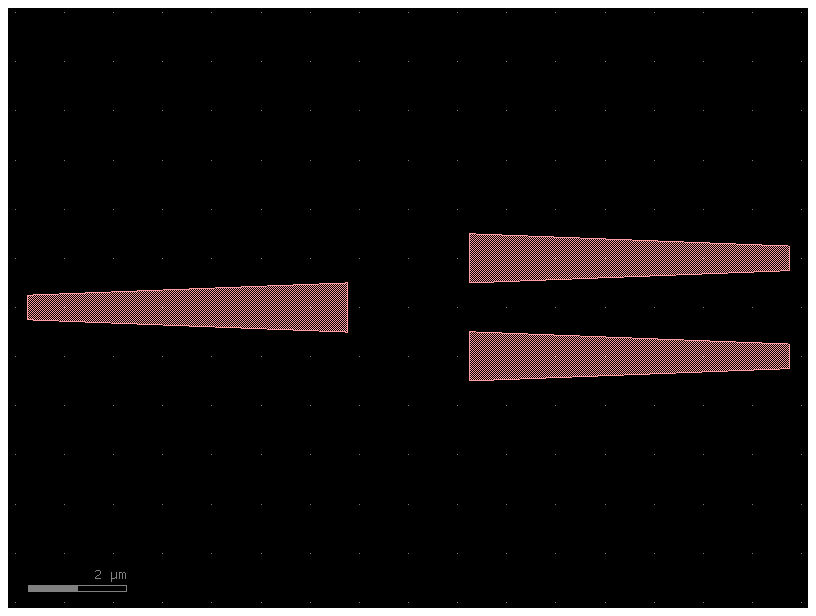

In [37]:
design_variables = MaterialGrid(Vector3(Nx, Ny), SiO2, Si, grid_type="U_MEAN")
design_region = DesignRegion(
    design_variables,
    volume=Volume(
        center=Vector3(),
        size=Vector3(design_region_width, design_region_height, 0),
    ),
)

c = gf.Component("mmi1x2")

arm_separation = 1.0
straight1 = c << gf.components.taper(6.5, width2=1)
straight1.dmove(straight1.ports["o2"].center, (-design_region_width / 2.0, 0))
straight2 = c << gf.components.taper(6.5, width1=1, width2=0.5)
straight2.dmove(straight2.ports["o1"].center, (design_region_width / 2.0, 1))
straight3 = c << gf.components.taper(6.5, width1=1, width2=0.5)
straight3.dmove(straight3.ports["o1"].center, (design_region_width / 2.0, -1))
c.add_port("o1", port=straight1.ports["o1"])
c.add_port("o2", port=straight2.ports["o2"])
c.add_port("o3", port=straight3.ports["o2"])

c.plot()

We define the objective function, and obtain the optimization object.


In [38]:
def mapping(x, eta, beta):
    # filter
    filtered_field = conic_filter(
        x,
        filter_radius,
        design_region_width,
        design_region_height,
        design_region_resolution,
    )

    # projection
    projected_field = tanh_projection(filtered_field, beta, eta)

    projected_field = (
        npa.fliplr(projected_field) + projected_field
    ) / 2  # up-down symmetry

    # interpolate to actual materials
    return projected_field.flatten()


seed = 240
np.random.seed(seed)
x0 = mapping(
    np.random.rand(Nx * Ny),
    eta_i,
    128,
)


def J(source, top, bottom):
    power = npa.abs(top / source) ** 2 + npa.abs(bottom / source) ** 2
    return npa.mean(power)


opt = gm.get_meep_adjoint_optimizer(
    c,
    J,
    [design_region],
    [design_variables],
    x0,
    resolution=resolution,
    cell_size=(
        Sx + 2 + design_region_width + 2 * pml_size,
        design_region_height + 2 * pml_size + 1.5,
    ),
    tpml=1.0,
    extend_ports_length=0,
    port_margin=1,
    port_source_offset=-5.5,
    port_monitor_offset=-5.5,
    symmetries=[mp.Mirror(direction=mp.Y)],
    wavelength_points=10,
)

NameError: name 'conic_filter' is not defined

We'll define a simple objective function that returns the gradient, and records the figure of merit. We'll plot the new geometry after each iteration.

```python


evaluation_history = []
cur_iter = [0]


def f(v, gradient, cur_beta):
    print(f"Current iteration: {cur_iter[0] + 1}")

    f0, dJ_du = opt([mapping(v, eta_i, cur_beta)])

    plt.figure()
    ax = plt.gca()
    opt.plot2D(
        False,
        ax=ax,
        plot_sources_flag=False,
        plot_monitors_flag=False,
        plot_boundaries_flag=False,
    )
    plt.show()

    if gradient.size > 0:
        gradient[:] = tensor_jacobian_product(mapping, 0)(
            v, eta_i, cur_beta, np.sum(dJ_du, axis=1)
        )

    evaluation_history.append(np.max(np.real(f0)))

    cur_iter[0] = cur_iter[0] + 1

    return np.real(f0)
```

We can define bitmasks to describe the boundary conditions.

```python

# Define spatial arrays used to generate bit masks
x_g = np.linspace(-design_region_width / 2, design_region_width / 2, Nx)
y_g = np.linspace(-design_region_height / 2, design_region_height / 2, Ny)
X_g, Y_g = np.meshgrid(x_g, y_g, sparse=True, indexing="ij")

# Define the core mask
left_wg_mask = (X_g == -design_region_width / 2) & (np.abs(Y_g) <= waveguide_width)
top_right_wg_mask = (X_g == design_region_width / 2) & (
    np.abs(Y_g + arm_separation) <= waveguide_width
)
bottom_right_wg_mask = (X_g == design_region_width / 2) & (
    np.abs(Y_g - arm_separation) <= waveguide_width
)
Si_mask = left_wg_mask | top_right_wg_mask | bottom_right_wg_mask

# Define the cladding mask
border_mask = (
    (X_g == -design_region_width / 2)
    | (X_g == design_region_width / 2)
    | (Y_g == -design_region_height / 2)
    | (Y_g == design_region_height / 2)
)
SiO2_mask = border_mask.copy()
SiO2_mask[Si_mask] = False
```

We can then finally run the optimizer, and visualize the optimized component.


```python
n = Nx * Ny  # number of parameters

# Initial guess
x = np.ones((n,)) * 0.5
x[Si_mask.flatten()] = 1  # set the edges of waveguides to silicon
x[SiO2_mask.flatten()] = 0  # set the other edges to SiO2

# lower and upper bounds
lb = np.zeros((Nx * Ny,))
lb[Si_mask.flatten()] = 1
ub = np.ones((Nx * Ny,))
ub[SiO2_mask.flatten()] = 0

cur_beta = 4
beta_scale = 2
num_betas = 7
update_factor = 12
run_optimization = False

if run_optimization:
    for iters in range(num_betas):
        print("current beta: ", cur_beta)

        if iters != num_betas - 1:
            x[:] = gm.run_meep_adjoint_optimizer(
                n,
                lambda a, g: f(a, g, cur_beta),
                x,
                lower_bound=lb,
                upper_bound=ub,
                maxeval=update_factor,
            )
        else:
            optimized_component = gm.run_meep_adjoint_optimizer(
                n,
                lambda a, g: f(a, g, cur_beta),
                x,
                lower_bound=lb,
                upper_bound=ub,
                maxeval=update_factor,
                get_optimized_component=True,
                opt=opt,
                threshold_offset_from_max=0.09,
            )
        cur_beta = cur_beta * beta_scale

    optimized_component.plot()
    final_figure_of_merit = 10 * np.log10(
        0.5 * np.array(evaluation_history[-1])
    )  # around -3.7 dB
```


The final optimized structure should look like this:

![optimized structure](https://user-images.githubusercontent.com/100642027/194617052-5cf0de3e-0294-441e-acad-9cd5e98ccd0b.png)

![optimization](https://user-images.githubusercontent.com/100642027/194617366-97b3e797-1fa4-40ed-8487-a5ac2b679493.png)

## Meep fields

Using the gplugins/gmeep utilities, we can also extract the output fields of the simulations.

This requires using a continuous source instead of the broad(er)band gaussian used in S-parameter extraction. Since we are working at a definite frequency, we can also leverage the [finite-difference frequency domain solver](https://meep.readthedocs.io/en/latest/Python_Tutorials/Frequency_Domain_Solver/).

In the spatial domain, this reuses the geometry and eigenmode source definitions of the plugin.

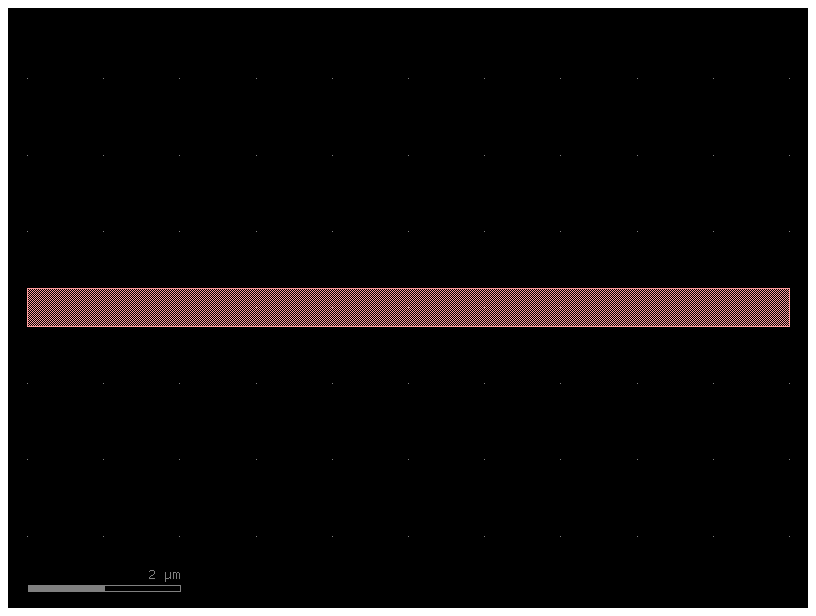

In [39]:
c = gf.components.straight(length=10)

component = gf.add_padding_container(
    c,
    default=0,
    top=3.2,
    bottom=3.2,
)

component.plot()

/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/__init__.py:4446: ComplexWarning: Casting complex values to real discards the imaginary part
  return _meep._get_epsilon_grid(gobj_list, mlist, _default_material, _ensure_periodicity, gv, cell_size, cell_center, nx, xtics, ny, ytics, nz, ztics, grid_vals, frequency)


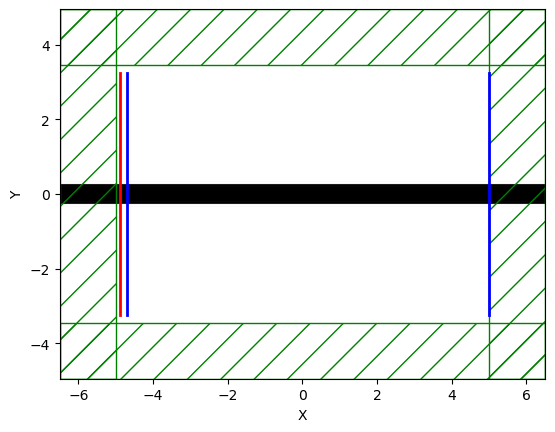

In [40]:
component = gf.add_padding_container(
    c,
    default=0,
    top=3.2,
    bottom=3.2,
)

sim_dict = get_simulation(
    component,
    is_3d=False,
    port_source_offset=-0.1,
    extend_ports_length=3,
    continuous_source=True,
    force_complex_fields=True,
)
sim = sim_dict["sim"]
sim.plot2D()
plt.show()

In [41]:
sim.init_sim()
sim.solve_cw(1e-6, 10000, 10)

/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/__init__.py:4440: ComplexWarning: Casting complex values to real discards the imaginary part
  return _meep.create_structure(cell_size, dft_data_list_, pml_1d_vols_, pml_2d_vols_, pml_3d_vols_, absorber_vols_, gv, br, sym, num_chunks, Courant, use_anisotropic_averaging, tol, maxeval, gobj_list, center, _ensure_periodicity, _default_material, alist, extra_materials, split_chunks_evenly, set_materials, existing_s, output_chunk_costs, my_bp)
/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/__init__.py:4443: ComplexWarning: Casting complex values to real discards the imaginary part
  return _meep._set_materials(s, cell_size, gv, use_anisotropic_averaging, tol, maxeval, gobj_list, center, _ensure_periodicity, _default_material, alist, extra_materials, split_chunks_evenly, set_materials, existing_geps, output_chunk_costs, my_bp)


True

In [42]:
sx = sim.cell_size.x
sy = sim.cell_size.y
dpml = sim.boundary_layers[0].thickness
nonpml_vol = mp.Volume(mp.Vector3(), size=mp.Vector3(sx - 2 * dpml, sy - 2 * dpml))
ez_dat = sim.get_array(vol=nonpml_vol, component=mp.Ez)

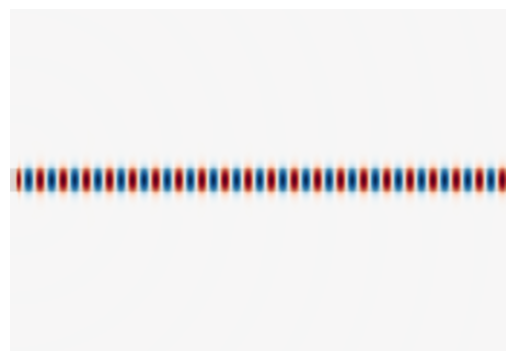

In [43]:
eps_data = sim.get_array(vol=nonpml_vol, component=mp.Dielectric)
ez_data = np.real(ez_dat)

plt.figure()
plt.imshow(eps_data.transpose(), interpolation="spline36", cmap="binary")
plt.imshow(ez_data.transpose(), interpolation="spline36", cmap="RdBu", alpha=0.9)
plt.axis("off")
plt.show()

We can also just run the time-domain simulation with the continuous source until the field is stabilized:

In [44]:
sim.run(until=400)

FloatProgress(value=0.0, description='0% done ', max=400.0)

/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/visualization.py:971: UserWarning: plot_sources_flag is deprecated. Use show_sources instead.
  warnings.warn("plot_sources_flag is deprecated. " "Use show_sources instead.")
/home/aitor/miniconda/envs/photonics/lib/python3.11/site-packages/meep/visualization.py:981: UserWarning: plot_boundaries_flag is deprecated. Use show_boundary_layers instead.
  warnings.warn(


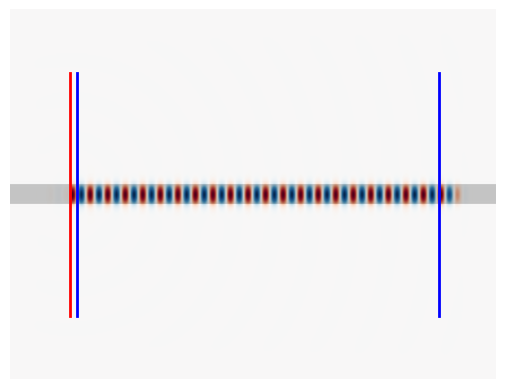

In [45]:
eps_data = sim.get_epsilon()
ez_data = np.real(sim.get_efield_z())


plt.figure()
sim.plot2D(
    fields=mp.Ez,
    plot_sources_flag=True,
    plot_monitors_flag=False,
    plot_boundaries_flag=True,
)
plt.axis("off")
plt.show()